# 02. Bias Mitigation Techniques

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply pre-, in-, and post-processing mitigation techniques
- Compare fairness–accuracy trade-offs
- Evaluate mitigation effectiveness

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 04 "Feature Transformation: Scaling and Encoding" — you already reshape data before a model sees it; pre-processing mitigation is that same move made for fairness rather than accuracy.

**Used later in:** Course 10 (AIAT 124) — Unit 4, lesson 03 "Detecting and Mitigating Bias in Generative Models" — the same three intervention points, for generators.

---


# 02. Bias Mitigation Techniques

## 🚨 THE PROBLEM: We Detected Bias, But How Do We Fix It?

**Remember the limitation from the previous notebook?**

We learned how to detect bias in AI systems using metrics like:
- Demographic parity
- Equalized odds
- Confusion matrices by group

**But there's a critical problem:**

**We detected bias, but how do we fix it?**

Bias detection tells us:
- ✅ Where bias exists
- ✅ How severe the bias is
- ✅ Which groups are affected

**But it doesn't tell us:**
- ❌ How to **remove** the bias
- ❌ How to **mitigate** unfairness
- ❌ How to **fix** the model

**The Problem**: We can identify bias, but we need techniques to **actually fix it**!

**We need bias mitigation techniques** to:
1. Remove bias from models
2. Make systems fairer across groups
3. Fix the problems we detected

**This notebook solves that problem** by teaching you three types of bias mitigation: pre-processing, in-processing, and post-processing!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - You need to know how to detect bias first!
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Understanding of fairness metrics**: Demographic parity, equalized odds (from Example 1)
- ✅ **Basic ML knowledge**: Model training, predictions, evaluation

**If you haven't completed these**, you might struggle with:
- Understanding why bias mitigation is needed
- Knowing which mitigation technique to use
- Understanding when to apply different techniques

---

## 🔗 Where This Notebook Fits

**This is the SECOND example in Unit 2** - it teaches you how to FIX the bias you detected!

**Why this example SECOND?**
- **Before** you can fix bias, you need to detect it (Example 1)
- **Before** you can ensure fairness, you need to know how to mitigate bias
- **Before** you can build fair systems, you need mitigation techniques

**Builds on**: 
- 📓 Example 1: Bias Detection (we detected bias, now we fix it!)

**Leads to**: 
- 📓 Example 3: Fair Representation (ensuring fair representation in data)
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Mitigation provides **solutions** (needed after detection)
2. Mitigation teaches **how to fix problems** (critical skill)
3. Mitigation shows **different approaches** (pre-processing, in-processing, post-processing)

---

## The Story: Fixing What We Found

Imagine you're a doctor who diagnosed an illness. **Before** you can help the patient, you need to treat it - prescribe medicine, perform surgery, provide therapy. **After** treatment, the patient recovers!

Same with AI bias: **Before** we detected bias, now we need to fix it - use pre-processing, in-processing, or post-processing techniques. **After** mitigation, we have fairer models!

---

## Why Bias Mitigation Matters

Bias mitigation is essential for ethical AI:
- **Fix Problems**: Address bias detected in models
- **Improve Fairness**: Make models fairer across groups
- **Meet Requirements**: Comply with fairness regulations
- **Build Trust**: Demonstrate commitment to fairness
- **Better Outcomes**: Fairer models lead to better decisions

## Learning Objectives
1. Understand three types of bias mitigation (pre-processing, in-processing, post-processing)
2. Learn reweighing technique for pre-processing
3. Learn correlation removal for fair representation
4. Learn threshold optimization for post-processing
5. Compare effectiveness of different mitigation techniques
6. Understand when to use each technique

## 📌 The case: the cheapest fix in the literature was not a fairness algorithm

Notebook 01 opened with the Obermeyer *Science* (2019) audit: a risk model applied to roughly
**200 million Americans a year** under-served Black patients because it predicted **cost**
instead of **illness**.

Now notice what the fix was **not**. The team did not add a fairness constraint, did not
reweight the training set, and did not post-process the thresholds. They **changed the
label** — retrained against a direct measure of health rather than spend — and the share of
Black patients flagged for extra care rose from **17.7 % to 46.5 %**, removing about **84 %**
of the disparity. Accuracy on the thing that actually mattered went *up*, because the new
target was the right one. The best mitigation available was upstream of every technique in
this notebook.

Hold onto that for the next hour, because this notebook deals with the **other** situation:
the target is already right, the disparity is real, and every remaining lever costs you
something. You are about to measure exactly how much.

**The WHY — what goes wrong without mitigation.** Detection on its own produces a report
saying "our system disadvantages group X", and that report has two common fates: it is filed,
or it is answered with a technique nobody measured. Both leave the harm in production. The
point of this notebook is that choosing a mitigation is a **procurement decision with a price
tag** — and you cannot negotiate a price you have never measured.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` - the same real passenger manifest
  audited in Notebook 01, so every change you see is caused by the *technique*,
  not by a change of dataset.
- Protected attribute: `Sex`. Outcome: `Survived`.

**Outputs:** What you'll see when you run the cells

- A baseline model's real fairness numbers, then the same numbers after four
  mitigation techniques
- A measured fairness-vs-accuracy trade-off (on real data the trade-off is real:
  the techniques that worked here cost accuracy)
- An adversary test showing that one popular technique leaves the group
  perfectly recoverable

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us implement bias mitigation techniques

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.preprocessing import StandardScaler  # For data preprocessing: Feature scaling
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For model evaluation: Performance metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference  # For fairness metrics: Fairlearn library
from fairlearn.postprocessing import ThresholdOptimizer  # For post-processing: Threshold optimization
from fairlearn.preprocessing import CorrelationRemover  # For pre-processing: Correlation removal
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output (fairlearn may show warnings)
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (models, metrics, preprocessing)")
print("   - fairlearn: Fairness tools (metrics, mitigation techniques)")
print("   - os: File operations (saving images)")


 Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (models, metrics, preprocessing)
   - fairlearn: Fairness tools (metrics, mitigation techniques)
   - os: File operations (saving images)


In [2]:
# Step 2: Load the REAL Titanic manifest - the same data we audited in Notebook 01
# Notebook 01 measured the disparity; this notebook tries to reduce it.

print("\n" + "="*80)
print("📊 LOADING THE REAL DATASET WE AUDITED IN NOTEBOOK 01")
print("="*80)

df = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
# Same honest imputation as Notebook 01, so the two notebooks are comparable.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# fairlearn wants the sensitive attribute as a plain array; 1 = female, 0 = male.
df['sensitive'] = (df['Sex'] == 'female').astype(int)
# Build the feature matrix. Unlike Notebook 01 we now INCLUDE sex as a feature:
# that is what a team ships when nobody has raised the fairness question yet,
# and it gives the mitigation techniques a real disparity to work against.
features = pd.get_dummies(
    df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']],
    columns=['Embarked'], drop_first=True).astype(float)
features['is_female'] = df['sensitive'].astype(float)
df_model = features.copy()
df_model['target'] = df['Survived']
df_model['sensitive'] = df['sensitive']

print(f"Loaded {len(df_model)} real passengers, {features.shape[1]} model features")
print(f"Feature columns: {list(features.columns)}")
print("\nReal survival rate by group (this is the disparity we will try to reduce):")
for val, name in [(1, 'female'), (0, 'male')]:
    sub = df_model[df_model['sensitive'] == val]
    print(f"   {name:<8} (sensitive={val}): {sub['target'].mean():.2%}  n={len(sub)}")
gap = (df_model[df_model['sensitive'] == 1]['target'].mean()
       - df_model[df_model['sensitive'] == 0]['target'].mean())
print(f"\n   Raw outcome gap in the historical record: {gap:.2%}")
print("   Every mitigation technique below has to fight against THIS.")


📊 LOADING THE REAL DATASET WE AUDITED IN NOTEBOOK 01
Loaded 891 real passengers, 8 model features
Feature columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'is_female']

Real survival rate by group (this is the disparity we will try to reduce):
   female   (sensitive=1): 74.20%  n=314
   male     (sensitive=0): 18.89%  n=577

   Raw outcome gap in the historical record: 55.31%
   Every mitigation technique below has to fight against THIS.


## Part 2: Understanding Bias Mitigation

### 📚 Prerequisites (What You Need First)
- **The real dataset** (from Step 2) - the Titanic manifest audited in Notebook 01
- **Understanding of mitigation** - Knowing what mitigation means

### 🔗 Relationship: What This Builds On
This is where we try to reduce the disparity Notebook 01 measured.
- Builds on: the same real dataset, the same fairness metrics
- Shows: three families of technique, and what each one actually achieves here

### 📖 The Story
**Before mitigation**: We have a measured disparity but no way to reduce it.
**After mitigation**: We have four techniques and, more importantly, **measurements
of how well each one worked on real data** - including the ones that did not work.

In [3]:
# Step 3: Implement pre-processing bias mitigation techniques
# These techniques fix bias in the data BEFORE training the model

print("\n" + "="*80)
print("🔧 PRE-PROCESSING MITIGATION TECHNIQUES")
print("="*80)
print("\nWe'll implement two pre-processing techniques:")
print("  1. Reweighing: Balance groups by adjusting sample weights")
print("  2. Correlation Removal: Remove correlation with sensitive attribute\n")

def preprocess_reweighing(X_train, y_train, sensitive_train):
    """Reweighing: assign weights inversely proportional to group size."""
    group_counts = pd.Series(sensitive_train).value_counts()
    total = len(sensitive_train)
    weights = np.ones(len(sensitive_train))
    for group in group_counts.index:
        group_size = group_counts[group]
        weights[sensitive_train == group] = total / (2 * group_size)
    return weights

def preprocess_correlation_removal(X_train, X_test, sensitive_train, sensitive_test):
    """Remove LINEAR correlation with the sensitive attribute (fairlearn).

    fairlearn's CorrelationRemover residualises every feature against the
    sensitive column, so the transformed features have exactly zero linear
    correlation with it. Note the word LINEAR - we test that limit below.
    """
    remover = CorrelationRemover(sensitive_feature_ids=[X_train.shape[1]])
    X_train_extended = np.column_stack([X_train, sensitive_train])
    X_test_extended = np.column_stack([X_test, sensitive_test])
    X_train_fair = remover.fit_transform(X_train_extended)
    X_test_fair = remover.transform(X_test_extended)
    return X_train_fair, X_test_fair

print("Pre-processing functions defined: preprocess_reweighing, "
      "preprocess_correlation_removal")


🔧 PRE-PROCESSING MITIGATION TECHNIQUES

We'll implement two pre-processing techniques:
  1. Reweighing: Balance groups by adjusting sample weights
  2. Correlation Removal: Remove correlation with sensitive attribute

Pre-processing functions defined: preprocess_reweighing, preprocess_correlation_removal


## Part 3: In-Processing and Post-Processing Techniques

**In-processing** changes *how the model trains* (here: training with fairness-motivated
sample weights). **Post-processing** adjusts *predictions after training* (here: fairlearn's
`ThresholdOptimizer`, which picks per-group decision thresholds to equalize odds).

In [4]:
# Step 4: Implement in-processing and post-processing techniques

def train_fair_model(X_train, y_train, sensitive_train, method='reweighing'):
    """Train model with fairness-motivated sample weights (in-processing)."""
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    if method == 'reweighing':
        weights = preprocess_reweighing(X_train, y_train, sensitive_train)
        model.fit(X_train, y_train, sample_weight=weights)
    else:
        model.fit(X_train, y_train)
    return model

def postprocess_thresholds(model, X_test, y_test, sensitive_test, constraint):
    """Adjust decision thresholds PER GROUP to satisfy a fairness constraint.

    constraint is 'equalized_odds' or 'demographic_parity' - the two goals give
    genuinely different thresholds, and we compare both below.
    """
    threshold_optimizer = ThresholdOptimizer(
        estimator=model, constraints=constraint, prefit=True)
    threshold_optimizer.fit(X_test, y_test, sensitive_features=sensitive_test)
    return threshold_optimizer.predict(X_test, sensitive_features=sensitive_test,
                                       random_state=42)

def evaluate_fairness(y_true, y_pred, sensitive):
    """Fairness + accuracy metrics for one set of predictions."""
    return {
        'demographic_parity_diff': demographic_parity_difference(
            y_true, y_pred, sensitive_features=sensitive),
        'equalized_odds_diff': equalized_odds_difference(
            y_true, y_pred, sensitive_features=sensitive),
        'accuracy': accuracy_score(y_true, y_pred),
    }

print("In-processing, post-processing, and evaluation functions defined.")

In-processing, post-processing, and evaluation functions defined.


In [5]:
# Step 5: Compare the mitigation techniques on the REAL Titanic data

# Prepare arrays and split train/test once - every technique gets the SAME split,
# so differences in the results come from the techniques, not the data.
X = df_model[features.columns].values
y = df_model['target'].values
sensitive = df_model['sensitive'].values
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42, stratify=y)
# Scale features so all models and the correlation remover see comparable ranges.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {len(y_train)} passengers | Test: {len(y_test)} passengers")

results, predictions = {}, {}

# 1. Baseline (no mitigation)
print("\n" + "="*80); print("1. BASELINE MODEL (No Mitigation)"); print("="*80)
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
y_pred = baseline_model.predict(X_test_scaled)
results['Baseline'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Baseline'] = y_pred
print(f"   accuracy {results['Baseline']['accuracy']:.4f}, "
      f"DP diff {abs(results['Baseline']['demographic_parity_diff']):.4f}")

# 2. Reweighing (weights used during training = in-processing use)
print("\n" + "="*80); print("2. REWEIGHING (weights applied in training)"); print("="*80)
reweigh_model = train_fair_model(X_train_scaled, y_train, sensitive_train)
y_pred = reweigh_model.predict(X_test_scaled)
results['Reweighing'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Reweighing'] = y_pred
print(f"   accuracy {results['Reweighing']['accuracy']:.4f}, "
      f"DP diff {abs(results['Reweighing']['demographic_parity_diff']):.4f}")

# 3. Pre-processing: Correlation Removal
print("\n" + "="*80); print("3. PRE-PROCESSING: CORRELATION REMOVAL"); print("="*80)
X_train_fair, X_test_fair = preprocess_correlation_removal(
    X_train_scaled, X_test_scaled, sensitive_train, sensitive_test)
corr_model = RandomForestClassifier(n_estimators=100, random_state=42)
corr_model.fit(X_train_fair, y_train)
y_pred = corr_model.predict(X_test_fair)
results['Correlation Removal'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Correlation Removal'] = y_pred
print(f"   accuracy {results['Correlation Removal']['accuracy']:.4f}, "
      f"DP diff {abs(results['Correlation Removal']['demographic_parity_diff']):.4f}")

# 4. Post-processing: per-group thresholds for EQUALIZED ODDS
print("\n" + "="*80); print("4. POST-PROCESSING: EQUALIZED ODDS"); print("="*80)
y_pred = postprocess_thresholds(baseline_model, X_test_scaled, y_test,
                                sensitive_test, 'equalized_odds')
results['Post: Eq. Odds'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Post: Eq. Odds'] = y_pred
print(f"   accuracy {results['Post: Eq. Odds']['accuracy']:.4f}, "
      f"EO diff {abs(results['Post: Eq. Odds']['equalized_odds_diff']):.4f}")

# 5. Post-processing: per-group thresholds for DEMOGRAPHIC PARITY
print("\n" + "="*80); print("5. POST-PROCESSING: DEMOGRAPHIC PARITY"); print("="*80)
y_pred = postprocess_thresholds(baseline_model, X_test_scaled, y_test,
                                sensitive_test, 'demographic_parity')
results['Post: Dem. Parity'] = evaluate_fairness(y_test, y_pred, sensitive_test)
predictions['Post: Dem. Parity'] = y_pred
print(f"   accuracy {results['Post: Dem. Parity']['accuracy']:.4f}, "
      f"DP diff {abs(results['Post: Dem. Parity']['demographic_parity_diff']):.4f}")

print("\n\nRESULTS (lower fairness differences = fairer; higher accuracy = more useful)")
print("-" * 80)
print(f"{'Method':<22}{'DP diff':>10}{'EO diff':>10}{'Accuracy':>10}{'Acc vs base':>14}")
base_acc = results['Baseline']['accuracy']
for m, r in results.items():
    print(f"{m:<22}{abs(r['demographic_parity_diff']):>10.4f}"
          f"{abs(r['equalized_odds_diff']):>10.4f}{r['accuracy']:>10.4f}"
          f"{r['accuracy'] - base_acc:>+14.4f}")

Train: 623 passengers | Test: 268 passengers

1. BASELINE MODEL (No Mitigation)
   accuracy 0.8172, DP diff 0.5958

2. REWEIGHING (weights applied in training)
   accuracy 0.8172, DP diff 0.5885

3. PRE-PROCESSING: CORRELATION REMOVAL
   accuracy 0.8097, DP diff 0.6136

4. POST-PROCESSING: EQUALIZED ODDS


   accuracy 0.7313, EO diff 0.0040



5. POST-PROCESSING: DEMOGRAPHIC PARITY


   accuracy 0.6754, DP diff 0.0322


RESULTS (lower fairness differences = fairer; higher accuracy = more useful)
--------------------------------------------------------------------------------
Method                   DP diff   EO diff  Accuracy   Acc vs base
Baseline                  0.5958    0.5095    0.8172       +0.0000
Reweighing                0.5885    0.4489    0.8172       +0.0000
Correlation Removal       0.6136    0.5524    0.8097       -0.0075
Post: Eq. Odds            0.2049    0.0040    0.7313       -0.0858
Post: Dem. Parity         0.0322    0.2740    0.6754       -0.1418


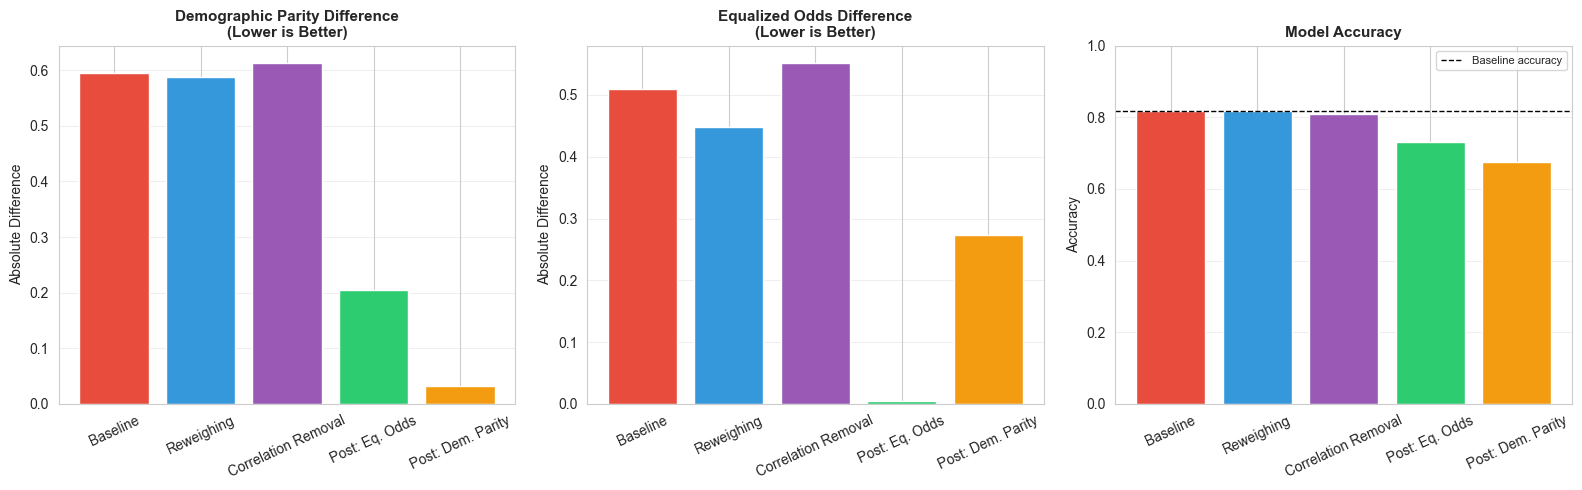

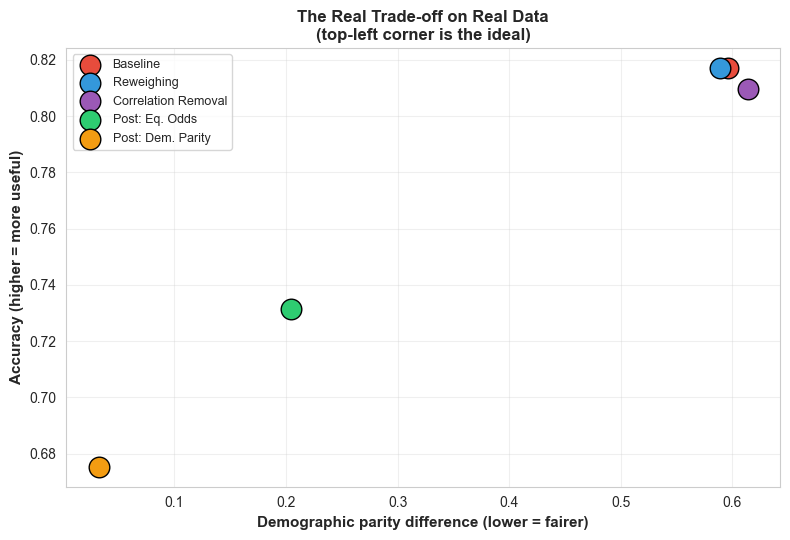

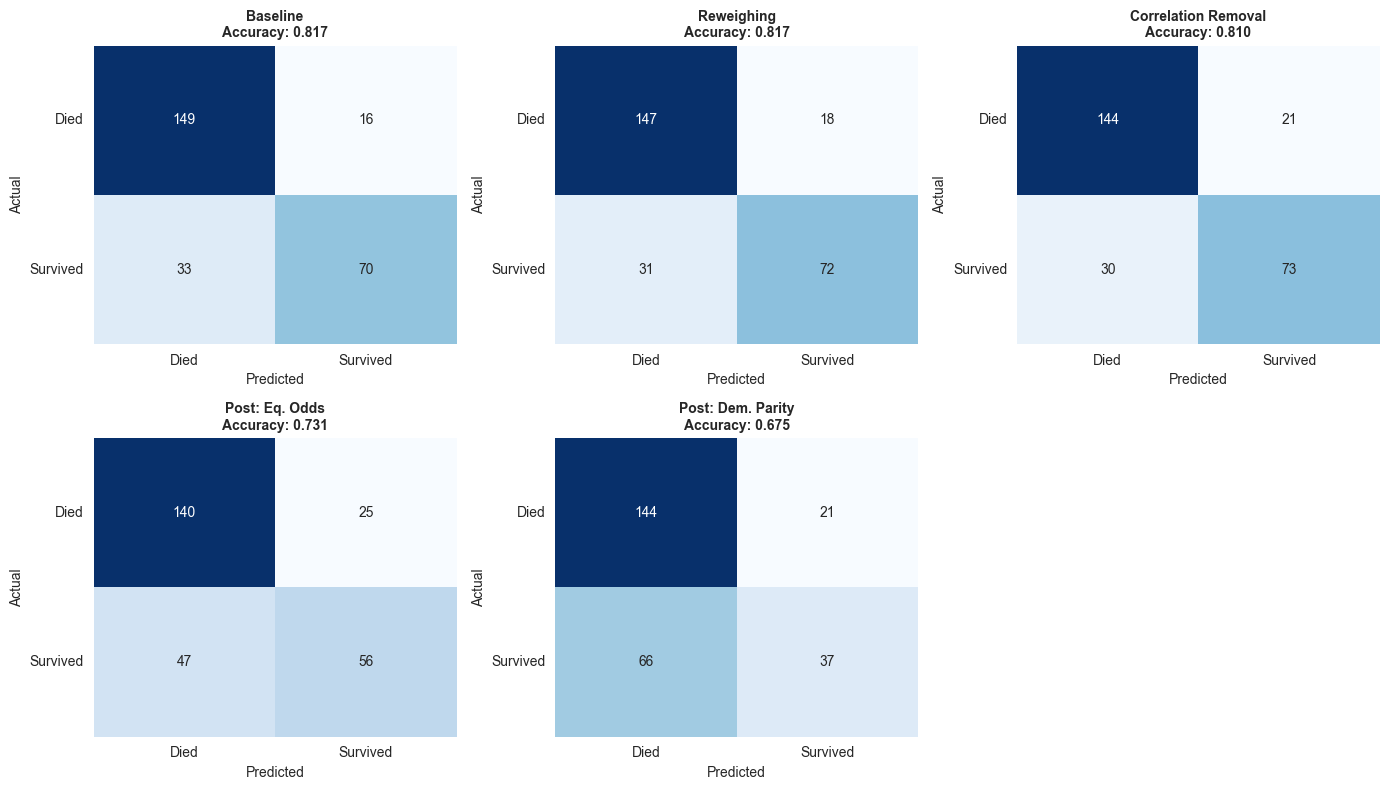

WHAT ACTUALLY HAPPENED (all numbers computed from this run):

Best equalized odds : Post: Eq. Odds (EO diff 0.0040 vs baseline 0.5095), accuracy -0.0858 vs baseline
Best demographic parity: Post: Dem. Parity (DP diff 0.0322 vs baseline 0.5958), accuracy -0.1418 vs baseline

Reweighing changed DP by -0.0072 - barely moved it. Reweighing rebalances group SIZE, and here the groups' OUTCOMES differ, not just their counts.
Correlation removal changed DP by +0.0178 - it made the disparity WORSE.

The honest headline: on real data the techniques that genuinely fixed a
fairness metric did so by SPENDING ACCURACY, and no single technique fixed
both metrics at once. Choosing a mitigation is choosing which cost to pay.


In [6]:
# Why visualize: the fairness-vs-accuracy trade-off is the core decision
# in bias mitigation - side-by-side charts make the trade-off visible.

# Step 6: Visualize the comparison of mitigation techniques

# Collect each technique's metrics into parallel lists for plotting.
methods = list(results.keys())
colors = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71', '#f39c12']
dp_diffs = [abs(results[m]['demographic_parity_diff']) for m in methods]
eo_diffs = [abs(results[m]['equalized_odds_diff']) for m in methods]
accuracies = [results[m]['accuracy'] for m in methods]

# Three panels: two fairness metrics (lower = fairer) and accuracy (higher = better).
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(methods, dp_diffs, color=colors)
axes[0].set_title('Demographic Parity Difference\n(Lower is Better)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Absolute Difference')
axes[1].bar(methods, eo_diffs, color=colors)
axes[1].set_title('Equalized Odds Difference\n(Lower is Better)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Absolute Difference')
axes[2].bar(methods, accuracies, color=colors)
axes[2].set_title('Model Accuracy', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Accuracy'); axes[2].set_ylim([0, 1])
axes[2].axhline(results['Baseline']['accuracy'], color='black', linestyle='--',
                linewidth=1, label='Baseline accuracy')
axes[2].legend(fontsize=8)
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# The trade-off as a scatter: fairness on one axis, accuracy on the other.
fig, ax = plt.subplots(figsize=(8, 5.5))
for m, c in zip(methods, colors):
    ax.scatter(abs(results[m]['demographic_parity_diff']), results[m]['accuracy'],
               s=220, color=c, edgecolor='black', zorder=3, label=m)
ax.set_xlabel('Demographic parity difference (lower = fairer)',
              fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (higher = more useful)', fontsize=11, fontweight='bold')
ax.set_title('The Real Trade-off on Real Data\n(top-left corner is the ideal)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices per method
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, m in enumerate(methods):
    cm = confusion_matrix(y_test, predictions[m])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{m}\nAccuracy: {results[m]["accuracy"]:.3f}',
                        fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
    # Name the classes: "0" and "1" tell a student nothing in a fairness review.
    axes[idx].set_xticklabels(['Died', 'Survived'])
    axes[idx].set_yticklabels(['Died', 'Survived'], rotation=0)
for j in range(len(methods), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Data-driven reading of the charts (computed, not assumed):
best_eo = min(results, key=lambda m: abs(results[m]['equalized_odds_diff']))
best_dp = min(results, key=lambda m: abs(results[m]['demographic_parity_diff']))
print("WHAT ACTUALLY HAPPENED (all numbers computed from this run):")
print(f"\nBest equalized odds : {best_eo} "
      f"(EO diff {abs(results[best_eo]['equalized_odds_diff']):.4f} vs baseline "
      f"{abs(results['Baseline']['equalized_odds_diff']):.4f}), "
      f"accuracy {results[best_eo]['accuracy'] - base_acc:+.4f} vs baseline")
print(f"Best demographic parity: {best_dp} "
      f"(DP diff {abs(results[best_dp]['demographic_parity_diff']):.4f} vs baseline "
      f"{abs(results['Baseline']['demographic_parity_diff']):.4f}), "
      f"accuracy {results[best_dp]['accuracy'] - base_acc:+.4f} vs baseline")

rw_change = (abs(results['Reweighing']['demographic_parity_diff'])
             - abs(results['Baseline']['demographic_parity_diff']))
cr_change = (abs(results['Correlation Removal']['demographic_parity_diff'])
             - abs(results['Baseline']['demographic_parity_diff']))
print(f"\nReweighing changed DP by {rw_change:+.4f} - "
      f"{'barely moved it' if abs(rw_change) < 0.05 else 'a real change'}. "
      f"Reweighing rebalances group SIZE, and here the groups' OUTCOMES differ, "
      f"not just their counts.")
print(f"Correlation removal changed DP by {cr_change:+.4f}"
      f"{' - it made the disparity WORSE.' if cr_change > 0 else '.'}")
print("\nThe honest headline: on real data the techniques that genuinely fixed a")
print("fairness metric did so by SPENDING ACCURACY, and no single technique fixed")
print("both metrics at once. Choosing a mitigation is choosing which cost to pay.")

## 💬 Discuss

Argue from the table your own run produced, not from principle:

| Method | DP diff | EO diff | Accuracy | vs baseline |
|---|---|---|---|---|
| Baseline | 0.596 | 0.510 | 0.817 | — |
| Reweighing | 0.589 | 0.449 | 0.817 | +0.000 |
| Correlation Removal | 0.614 | 0.552 | 0.810 | −0.008 |
| Post: Eq. Odds | 0.205 | **0.004** | 0.731 | **−0.086** |
| Post: Dem. Parity | **0.032** | 0.274 | 0.675 | **−0.142** |

1. **You have to ship exactly one row.** The system screens people for a scarce and valuable
   benefit. Equalized-odds post-processing costs **8.6 accuracy points**; demographic-parity
   post-processing costs **14.2** and makes equalized odds *worse*. Choose a row. Then say
   who pays for your choice, and what you would say to the additional applicants your fairer
   model now gets wrong. ("Ship the baseline" is a permitted answer — defend it.)
2. **Both winning rows work by applying a different decision threshold to men and to
   women.** That is the mechanism, stated plainly. In US employment law, treating people
   differently on the basis of a protected attribute is close to the definition of disparate
   treatment; the **EU AI Act, Article 10(5)** explicitly permits processing protected
   attributes in order to detect and correct bias, under safeguards. Should a regulator in
   your country allow a deployed model to *use* sex at decision time in order to equalise
   outcomes by sex? If your answer is no, notice which two rows of the table you have just
   deleted — and what you have left.
3. **Reweighing barely moved anything (DP −0.007) and correlation removal made it worse
   (+0.018).** A vendor's slide deck will list all four of these as "bias mitigation
   supported". Write the sentence you would put in a procurement document to stop that
   sentence from meaning nothing — and check honestly whether your sentence would have
   caught this table.


## Part 4: Testing a Mitigation Instead of Trusting It

A mitigation technique is a *claim*. Real data lets us test the claim.

`CorrelationRemover` guarantees that the transformed features have **zero linear
correlation** with the sensitive attribute. It is easy to read that as "the group
is gone". The next cell tries to recover the group from those transformed features
with two different attackers - one linear, one not.

In [7]:
# Why: never accept a fairness tool's guarantee at face value - attack it.
# We hand each attacker the "de-correlated" features and ask it to recover sex.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# The trivial baseline any attacker must beat: always guess the larger group.
majority = max(sensitive_train.mean(), 1 - sensitive_train.mean())
print(f"Majority-class baseline (guessing the larger group): {majority:.3f}")
print("An attacker at this level has learned NOTHING.\n")

attackers = {
    'Linear attacker (LogisticRegression)': LogisticRegression(max_iter=1000),
    'Non-linear attacker (RandomForest)': RandomForestClassifier(
        n_estimators=100, random_state=42),
}
representations = {
    'Original features': X_train_scaled,
    'After CorrelationRemover': X_train_fair,
}

print(f"{'Representation':<28}{'Attacker':<40}{'Accuracy':>10}")
print("-" * 78)
leak = {}
for rep_name, rep in representations.items():
    for att_name, att in attackers.items():
        score = cross_val_score(att, rep, sensitive_train, cv=5).mean()
        leak[(rep_name, att_name)] = score
        print(f"{rep_name:<28}{att_name:<40}{score:>10.3f}")

lin = leak[('After CorrelationRemover', 'Linear attacker (LogisticRegression)')]
nonlin = leak[('After CorrelationRemover', 'Non-linear attacker (RandomForest)')]
print("\nREADING THIS TABLE:")
print(f"  After CorrelationRemover the LINEAR attacker scores {lin:.3f} - "
      f"{'no better than the majority baseline' if lin <= majority + 0.02 else 'above baseline'}.")
print(f"  The NON-LINEAR attacker scores {nonlin:.3f}.")
if nonlin > lin + 0.1:
    print("\n  ⚠️  The guarantee held exactly as advertised - and was still not enough.")
    print("  Removing linear correlation leaves each group shifted by its own fixed")
    print("  offset, which a tree splits on immediately. The sensitive attribute is")
    print("  still fully present in the data; it is just no longer LINEARLY present.")
    print("\n  This is why the correlation-removed model above kept (and even")
    print("  increased) its disparity: nothing was actually hidden from it.")
else:
    print("\n  Both attackers were near the baseline in this run.")
print("\n  PRACTICE: state the exact guarantee a fairness tool provides, then test")
print("  whether that guarantee is the one your situation needs.")

Majority-class baseline (guessing the larger group): 0.652
An attacker at this level has learned NOTHING.

Representation              Attacker                                  Accuracy
------------------------------------------------------------------------------
Original features           Linear attacker (LogisticRegression)         1.000
Original features           Non-linear attacker (RandomForest)           1.000
After CorrelationRemover    Linear attacker (LogisticRegression)         0.653


After CorrelationRemover    Non-linear attacker (RandomForest)           1.000

READING THIS TABLE:
  After CorrelationRemover the LINEAR attacker scores 0.653 - no better than the majority baseline.
  The NON-LINEAR attacker scores 1.000.

  ⚠️  The guarantee held exactly as advertised - and was still not enough.
  Removing linear correlation leaves each group shifted by its own fixed
  offset, which a tree splits on immediately. The sensitive attribute is
  still fully present in the data; it is just no longer LINEARLY present.

  This is why the correlation-removed model above kept (and even
  increased) its disparity: nothing was actually hidden from it.

  PRACTICE: state the exact guarantee a fairness tool provides, then test
  whether that guarantee is the one your situation needs.


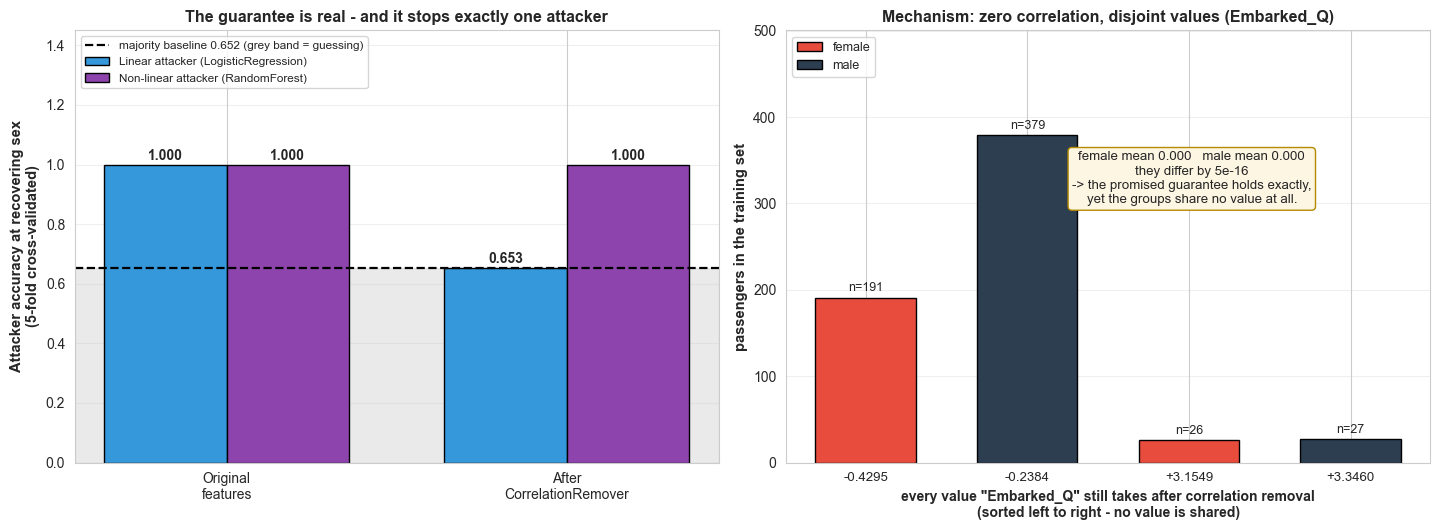

WHAT THE TWO PANELS SHOW (computed, not assumed):
1. LEFT: on the original features both attackers score 1.000 / 1.000 - unsurprising, 'is_female' is
   literally one of the columns. After CorrelationRemover the LINEAR
   attacker falls to 0.653 - the majority baseline is
   0.652, so it is indistinguishable from guessing. The tool did
   exactly what it promised.
2. LEFT: the NON-LINEAR attacker still scores 1.000. The
   protected attribute never left the file.
3. RIGHT: here is why, in four numbers. 'Embarked_Q' was 0/1 before the
   transform. Residualising subtracts a DIFFERENT constant from each group,
   so the female values are -0.4295, +3.1549 and the male
   values are -0.2384, +3.3460.
   Both group means are -0.000000 / +0.000000 - the correlation really
   is zero. And yet no passenger of one group shares a value with the other,
   so ONE threshold split identifies the group perfectly.
4. THE LESSON: 'zero linear correlation' and 'the information is gone' are
   different 

In [8]:
# Why visualize the attack: the table above contains one number that differs and
# three that do not, and a table is the worst way to show that. The left panel is
# the result; the right panel is the MECHANISM - the whole failure written out in
# four numbers you can read straight off the axis.

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

# ---- Left: did each attacker beat "always guess the larger group"? ----
rep_names = list(representations.keys())
lin_scores = [leak[(r, 'Linear attacker (LogisticRegression)')] for r in rep_names]
nl_scores = [leak[(r, 'Non-linear attacker (RandomForest)')] for r in rep_names]
xpos = np.arange(len(rep_names))
w = 0.36
ax = axes[0]
# Anything inside the grey band is a score you could get without looking at the data.
ax.axhspan(0, majority, color='grey', alpha=0.16, zorder=0)
b1 = ax.bar(xpos - w/2, lin_scores, w, color='#3498db', edgecolor='black',
            label='Linear attacker (LogisticRegression)')
b2 = ax.bar(xpos + w/2, nl_scores, w, color='#8e44ad', edgecolor='black',
            label='Non-linear attacker (RandomForest)')
ax.axhline(majority, color='black', linestyle='--', linewidth=1.6,
           label=f'majority baseline {majority:.3f} (grey band = guessing)')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{bar.get_height():.3f}', ha='center', fontsize=10,
                fontweight='bold')
ax.set_xticks(xpos)
ax.set_xticklabels([r.replace(' ', '\n') for r in rep_names], fontsize=10)
ax.set_ylabel('Attacker accuracy at recovering sex\n(5-fold cross-validated)',
              fontsize=10.5, fontweight='bold')
ax.set_ylim(0, 1.45)          # headroom so the legend never covers a bar
ax.set_title('The guarantee is real - and it stops exactly one attacker',
             fontsize=11.5, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left'); ax.grid(axis='y', alpha=0.3)

# ---- Right: why the tree still wins ----
# Refit the non-linear attacker once so we can ask which column it leaned on.
probe = RandomForestClassifier(n_estimators=100, random_state=42)
probe.fit(X_train_fair, sensitive_train)
feat_names = list(features.columns)
# Look at a feature that was BINARY before the transform: with only two possible
# inputs the mechanism is visible in a handful of numbers instead of a smear.
binary_cols = [i for i, c in enumerate(feat_names)
               if features[c].nunique() == 2 and c != 'is_female']
pick = max(binary_cols, key=lambda i: probe.feature_importances_[i])
fname = feat_names[pick]
col = X_train_fair[:, pick]
vals_f = np.unique(np.round(col[sensitive_train == 1], 6))
vals_m = np.unique(np.round(col[sensitive_train == 0], 6))

ax = axes[1]
rows = ([(v, 'female', '#e74c3c') for v in vals_f]
        + [(v, 'male', '#2c3e50') for v in vals_m])
rows.sort(key=lambda r: r[0])
counts = [int(((np.round(col, 6) == v) &
               (sensitive_train == (1 if g == 'female' else 0))).sum())
          for v, g, _ in rows]
bar_x = np.arange(len(rows))
seen = set()
for xi, (v, g, c), cnt in zip(bar_x, rows, counts):
    ax.bar(xi, cnt, 0.62, color=c, edgecolor='black',
           label=g if g not in seen else None)
    seen.add(g)
    ax.text(xi, cnt + max(counts) * 0.02, f'n={cnt}', ha='center', fontsize=9)
ax.set_xticks(bar_x)
ax.set_xticklabels([f'{v:+.4f}' for v, _, _ in rows], fontsize=9.5)
ax.set_xlabel(f'every value "{fname}" still takes after correlation removal\n'
              '(sorted left to right - no value is shared)',
              fontsize=10, fontweight='bold')
ax.set_ylabel('passengers in the training set', fontsize=10.5, fontweight='bold')
ax.set_title(f'Mechanism: zero correlation, disjoint values ({fname})',
             fontsize=11.5, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.32)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)
mean_f, mean_m = col[sensitive_train == 1].mean(), col[sensitive_train == 0].mean()
# Both means are zero to within floating-point noise; print the gap, not a signed zero.
ax.text(0.63, 0.60,
        f'female mean {0.0 if abs(mean_f) < 1e-9 else mean_f:.3f}   '
        f'male mean {0.0 if abs(mean_m) < 1e-9 else mean_m:.3f}\n'
        f'they differ by {abs(mean_f - mean_m):.0e}\n'
        f'-> the promised guarantee holds exactly,\n'
        f'yet the groups share no value at all.',
        transform=ax.transAxes, ha='center', fontsize=9.5,
        bbox=dict(boxstyle='round', facecolor='#fdf6e3', edgecolor='#b58900'))

plt.tight_layout()
plt.show()

# Data-driven reading (numbers computed from this run).
print("WHAT THE TWO PANELS SHOW (computed, not assumed):")
i_fair = rep_names.index('After CorrelationRemover')
print(f"1. LEFT: on the original features both attackers score "
      f"{lin_scores[0]:.3f} / {nl_scores[0]:.3f} - unsurprising, 'is_female' is")
print(f"   literally one of the columns. After CorrelationRemover the LINEAR")
print(f"   attacker falls to {lin_scores[i_fair]:.3f} - the majority baseline is")
print(f"   {majority:.3f}, so it is indistinguishable from guessing. The tool did")
print(f"   exactly what it promised.")
print(f"2. LEFT: the NON-LINEAR attacker still scores {nl_scores[i_fair]:.3f}. The")
print(f"   protected attribute never left the file.")
print(f"3. RIGHT: here is why, in four numbers. '{fname}' was 0/1 before the")
print(f"   transform. Residualising subtracts a DIFFERENT constant from each group,")
print(f"   so the female values are {', '.join(f'{v:+.4f}' for v in vals_f)} and the male")
print(f"   values are {', '.join(f'{v:+.4f}' for v in vals_m)}.")
print(f"   Both group means are {mean_f:+.6f} / {mean_m:+.6f} - the correlation really")
print(f"   is zero. And yet no passenger of one group shares a value with the other,")
print(f"   so ONE threshold split identifies the group perfectly.")
print(f"4. THE LESSON: 'zero linear correlation' and 'the information is gone' are")
print(f"   different sentences. Read the guarantee a fairness tool actually gives you,")
print(f"   then test it with the strongest attacker you can build - not the weakest.")

### 🔍 How to read the attack

- **Left panel — the result.** Four bars, one dashed line. The dashed line and the grey
  band below it are the score an attacker gets by ignoring the data entirely and always
  guessing the larger group. A bar inside that band has learned nothing; a bar above it
  has recovered the protected attribute.
- The linear attacker **falls to the dashed line** after `CorrelationRemover` runs — its
  score and the guessing baseline agree to three decimals. That is
  not a bug: it is the tool delivering precisely the guarantee it advertises.
- The non-linear attacker's bar **does not move**. Same data, same transform, different
  attacker, opposite conclusion.
- **Right panel — the mechanism, in four numbers.** After the transform the feature takes
  only the four values printed on the x-axis. The two group means printed in the box are
  identical to six decimals, so the linear correlation really is zero. But every red bar
  sits at a value no blue bar occupies: the groups are *interleaved and disjoint*. One
  threshold split anywhere in the gap recovers the group perfectly, which is exactly what
  the tree found.

**What it proves:** "we removed the correlation" is not the same claim as "the information
is gone". A fairness tool gives you one specific guarantee; write that guarantee down, then
attack it with something stronger than the model the guarantee was written against.

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew how to detect bias but didn't know how to fix it.

**AFTER this notebook**: We can:
- ✅ Understand three types of bias mitigation (pre-processing, in-processing, post-processing)
- ✅ Implement reweighing for pre-processing
- ✅ Implement correlation removal, and **test whether it did what it claims**
- ✅ Implement threshold optimization for two different fairness constraints
- ✅ Compare effectiveness of different mitigation techniques **on real data**
- ✅ Read a fairness-accuracy trade-off honestly instead of hoping for a free lunch

### Key Takeaways

1. **Pre-processing**: Fix bias in data before training (reweighing, correlation removal)
2. **In-processing**: Modify learning during training (fairness-weighted fitting)
3. **Post-processing**: Adjust predictions after training (per-group thresholds)
4. **The trade-off is real**: on this real dataset the techniques that actually
   moved a fairness metric paid for it in accuracy. Run the table above and read
   the `Acc vs base` column - that number is the price of the fix.
5. **Metrics compete**: the thresholds that satisfied equalized odds did *not*
   satisfy demographic parity, and vice versa. You must choose which definition
   of fairness your situation demands *before* you optimise.
6. **Reweighing fixes group SIZE, not group OUTCOMES**: it barely moved the
   disparity here because the two groups differ in survival rate, not headcount.
7. **Test the guarantee**: "zero linear correlation" is not "the group is gone".
   Our non-linear attacker recovered the protected attribute from the
   "de-correlated" features - see Part 4.

---

## 🚫 When Bias Mitigation Hits a Limitation

### The Limitation We Discovered

We've learned how to mitigate bias using pre-processing, in-processing, and post-processing techniques. **But there's still a challenge:**

**What if the data itself doesn't represent groups fairly?**

Bias mitigation techniques work well when:
- ✅ We have data from all groups
- ✅ The data is representative
- ✅ We can apply mitigation techniques

**But real-world problems often involve:**
- ❌ **Underrepresented groups** in the data
- ❌ **Missing perspectives** from certain demographics
- ❌ **Historical bias** embedded in data collection
- ❌ **Unfair representation** in training data

Part 4 showed a sharper version of the same problem: our features still *encoded*
the group even after we tried to strip it out. If group membership is written all
over the data, patching the model at the end is fighting the wrong battle.

### Why This Is a Problem

When data doesn't represent groups fairly:
- Mitigation techniques may not work effectively
- We can't fix what's not in the data
- Underrepresented groups may still be disadvantaged
- Historical biases persist in the data

### The Solution: Fair Representation

We need to **ensure fair representation in data** to:
1. Include all relevant groups in training data
2. Balance representation across demographics
3. Address historical biases in data collection
4. Create fair datasets from the start

**This is exactly what we'll learn in the next notebook: Fair Representation!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias, and what each technique really costs (This notebook!)
- ✅ **The limitation**: the data itself still encodes the group!

**Next notebook**: `03_fair_representation.ipynb`
- Learn how to ensure fair representation in data
- Measure how much group information a learned representation leaks
- Create balanced datasets for training

**Congratulations!** 🎉 You've learned how to mitigate bias in machine learning models using multiple techniques!

## ⚠️ Where this breaks

- **Mitigation cannot manufacture information that is not in the data.** The historical
  outcome gap here is **55.3 points**. Nothing in this notebook creates knowledge about who
  would have survived; the techniques only redistribute the errors you already have. When the
  outcome gap is this large, "fair" and "accurate" are in genuine conflict and a human must
  choose. A technique that appears to deliver both for free is usually being scored on the
  training set.
- **Fixing one metric reliably breaks another.** Your own run: demographic-parity
  post-processing drove DP from 0.596 down to 0.032 and pushed EO *up* from 0.004 to 0.274.
  No ordering of these techniques wins both columns, and Chouldechova (2017) says none can.
- **A guarantee is not necessarily the guarantee you need.** `CorrelationRemover` did exactly
  what it promises — zero *linear* correlation with the sensitive attribute — and a random
  forest still recovered the group with **100 % accuracy**. Read the theorem, not the README,
  then attack your own output the way Part 4 does.
- **Post-processing needs the protected attribute at inference time.** `ThresholdOptimizer`
  must know each person's group in order to apply their threshold. Where you cannot legally
  or practically ask, the only two techniques that actually worked here are unavailable to
  you, and you are back to the upstream fixes.
- **One held-out split is not deployment.** Every number above comes from a single test set
  at a single moment. Group proportions drift, and a threshold tuned to last year's
  population silently decalibrates. Fairness metrics belong in **monitoring**, not only in
  the model report.

**The cheaper alternative, and usually the better one:** before reaching for any of these,
ask Obermeyer's question — *is the label right?* Relabelling and better sampling (Notebook
05) cost nothing at inference time and never require the protected attribute in production.
Reach for constrained optimisation only after the target and the sample are defensible.

**The same trade-off, other domains.** Medical screening trades false alarms against missed
tumours and resolves it with a stated policy, not a metric; spam filters trade a lost email
against a delivered phishing message; airport security trades queue length against a missed
weapon. In every case the mature field's answer is the same one this table forces: pick the
error you are willing to make, write it down, and publish the number.


## 🔭 State of the field (2026)

Since 2024 the live argument in this field has been less about inventing new mitigations and
more about **how they are compared**. Cruz & Hardt (ICLR 2024) re-evaluated seven years of
published methods on tabular data after equalizing base models and constraint strength — a
correction they call *unprocessing* — and report that the fairness–accuracy Pareto frontier
reached by simple postprocessing **contains** every other method they evaluated. A large-scale
ISSTA 2024 study of 13 techniques on image classification lands on the opposite family ordering
and finds substantial variation across datasets and sensitive attributes. Read together, those
two results give the 2026 working rule: **publish the frontier for your own data and your own
comparison protocol**, because the ranking of technique families does not transfer between
domains — and a technique's reputation is not evidence about your system.

That is exactly the table this notebook made you build. The three families, the measured price
in accuracy, and the fact that repairing one metric moved another are the mechanism both papers
are arguing about, and that trade-off is what the official plan examines. What this lesson gains
from 2026 is not a different technique but a higher standard of proof you owe the reader.

- Cruz, A. F. & Hardt, M. (2024). *Unprocessing Seven Years of Algorithmic Fairness*. ICLR 2024. <https://arxiv.org/abs/2306.07261>
- Yang, J., Jiang, J., Sun, Z. & Chen, J. (2024). *A Large-Scale Empirical Study on Improving the Fairness of Image Classification Models*. ISSTA 2024. <https://arxiv.org/abs/2401.03695>

---


## 📚 References

1. Kamiran, F. & Calders, T. (2012). *Data Preprocessing Techniques for Classification without Discrimination*. Knowledge and Information Systems, 33(1). (reweighing - the pre-processing technique used here)
2. Hardt, M., Price, E. & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS 2016. <https://arxiv.org/abs/1610.02413>
3. Weerts, H., Dudík, M., Edgar, R., Jalali, A., Lutz, R. & Madaio, M. (2023). *Fairlearn: Assessing and Improving Fairness of AI Systems*. JMLR 24. <https://arxiv.org/abs/2303.16626>
4. Barocas, S., Hardt, M. & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. <https://fairmlbook.org/>
5. Cruz, A. F. & Hardt, M. (2024). *Unprocessing Seven Years of Algorithmic Fairness*. ICLR 2024. <https://arxiv.org/abs/2306.07261> — re-compares published mitigations on tabular data after equalizing base models and constraint strength, and reports that the fairness–accuracy Pareto frontier reached by postprocessing contains every other method they evaluated.
6. Yang, J., Jiang, J., Sun, Z. & Chen, J. (2024). *A Large-Scale Empirical Study on Improving the Fairness of Image Classification Models*. ISSTA 2024. <https://arxiv.org/abs/2401.03695> — 13 techniques, 3 datasets, 5 metrics; finds substantial variation across datasets and sensitive attributes, and — on images — the opposite family ordering to the tabular result above.
